# Seleção de modelos — Seoul Bike Sharing 2015–2024 (notebook 04)

Neste quarto notebook da série v4, estimators de regressão são selecionados, otimizados e comparados exclusivamente sobre os dados de desenvolvimento. O holdout final permanece selado para o notebook 05. A busca conjunta do estimator, da representação, do encoder, da função de perda, da estratégia de orçamento do boosting e da estratégia do alvo é mantida como contrato central do projeto.

O objetivo preditivo passa a ser declarado como demanda em condições operacionais normais. O ano civil de 2020 é preservado na fonte e em diagnósticos de estresse, mas suas observações não são utilizadas no ajuste nem na métrica primária de seleção. Todos os estimators são reabertos sob essa mesma definição para que o CatBoost não seja promovido por herança de um regime anterior.

## 1. Ambiente, idioma e parâmetros de visualização

Toda a execução é realizada sob o ambiente conda `Bike-Sharing`, e a conferência é feita pelo próprio interpretador, por meio de `sys.prefix` e `sys.executable`. A verificação é levantada antes do carregamento dos dados, da criação dos estudos Optuna e da abertura das runs no MLflow, de modo que uma execução em ambiente incorreto seja interrompida antes da produção de artefatos.

O relatório de ambiente é exibido como evidência de auditoria do notebook salvo, junto das versões das bibliotecas que determinam os resultados e do fingerprint que resume esse conjunto.

O português é mantido como idioma canônico desta versão. A camada `multilang`, acessada por `make_lang('pt')`, é aplicada aos títulos, aos relatórios e às saídas visíveis, sem que nomes internos de variáveis ou parâmetros sejam traduzidos. Os parâmetros gráficos compartilhados são reaplicados para que a apresentação permaneça uniforme.

In [1]:
import logging
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = next(
    filter(
        lambda candidate: (
            (candidate / 'src').is_dir()
            and (candidate / 'notebooks').is_dir()
        ),
        (Path.cwd(), *Path.cwd().parents),
    )
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt

from src import model_selection_reports as reports
from src.i18n import make_lang
from src.model_selection_workflow import (
    load_model_selection_results,
    ModelSelectionConfig,
    prepare_development_data,
    run_model_selection,
    sample_dynamic_pipeline,
)
from src.normal_operations import NORMAL_OPERATIONS_SEED_TRIALS
from src.plotting import set_graph_parameters

warnings.filterwarnings('ignore', category=FutureWarning)
logging.getLogger('matplotlib.category').setLevel(logging.WARNING)

lang = make_lang('pt')
set_graph_parameters()
plt.rcParams['axes.grid'] = False
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
reports.environment_report(lang=lang)

,Item,Valor
0,Ambiente conda,Bike-Sharing
1,Interpretador (sys.executable),CONDA_PREFIX\py...
2,Versão do Python,3.10.20
3,Fingerprint do ambiente,8f80d9216d47a792
4,Divergências em relação ao environment.yml,nenhuma
5,Requisitos declarados no modelo,"mlflow==2.10.0, cloudpickle==3.1.2, numpy==1.2..."
6,scikit-learn,1.3.2
7,pandas,2.2.3
8,numpy,1.26.4
9,mlflow,2.10.0


## 2. Configuração declarativa da execução

Toda a execução é descrita por uma única configuração. No modo `full`, Ridge, HistGradientBoosting, XGBoost, LightGBM, Random Forest e CatBoost serão avaliados por até 100 trials ou quatro horas por estimator, prevalecendo o limite atingido primeiro. O modo `smoke` limita cada estudo a duas trials e é utilizado apenas para validar o fluxo completo antes da execução definitiva.

O perfil `refined` mantém o pré-processamento dinâmico condicionado à família do estimator. Para XGBoost, LightGBM e CatBoost, a estratégia de orçamento também é escolhida por trial: o número de árvores pode ser descoberto por early stopping em uma cauda temporal interna ou pode ser estimado diretamente como um orçamento fixo. A transformação `target_transform='none'` permanece disponível somente para o CatBoost direto.

Configurações competitivas do protocolo anterior são enfileiradas como hipóteses iniciais e contam no limite de 100 trials. Nenhuma delas é tratada como vencedora antecipadamente. Os pesos `(1, 1, 2, 3)` são associados, nessa ordem, aos folds normais de 2019, 2021, 2022 e 2023. O fold de 2020 é preservado como estresse e não recebe peso na seleção.

In [3]:
config = ModelSelectionConfig(
    run_mode='full',  # smoke validado; execução definitiva: 100 trials ou 4 h
    estimators=(
        'Ridge',
        'HistGradientBoostingRegressor',
        'XGBRegressor',
        'LGBMRegressor',
    ),
    include_random_forest=True,
    include_catboost=True,
    trials_per_estimator=100,
    study_timeout=14_400.0,
    n_challengers=2,
    train_window_years=None,
    fold_weights=(1.0, 1.0, 2.0, 3.0),
    search_profile='refined',
    target_strategy='auto',
    selection_metric='cv_mae_weighted',
    candidates_root=PROJECT_ROOT / 'dataset' / 'normal_operations',
    enqueued_trials_by_estimator=NORMAL_OPERATIONS_SEED_TRIALS,
)
reports.run_configuration_report(config, lang=lang)

,Item,Valor
0,Modo de execução,full
1,Estimators candidatos,"Ridge, HistGradientBoostingRegressor, XGBRegre..."
2,Trials por estimator (total configurado),100
3,Timeout por trial (s),1800.0
4,Timeout por estudo (s),14400.0
5,Timeout específico por estimator (s),{}
6,Challengers congelados,2
7,Congela candidatos definitivos,True
8,Versão da estratégia de CV,ForwardMeteorologicalYearSplit_v3_normal_opera...
9,Versão do código,temporal_optimizer_v7


## 3. Preparação dos dados e selagem do holdout

O holdout final é separado por data, entre 1º de dezembro de 2023 e 30 de novembro de 2024, e não por uma contagem de linhas. As observações desse período são descartadas dentro da função de separação, que devolve apenas o conjunto de desenvolvimento e um resumo sem dados de linha. Em nenhum momento deste notebook é materializada uma variável contendo observações do holdout.

O desenvolvimento é definido como a fatia estritamente anterior ao início do holdout. Como a fonte se estende até 31 de dezembro de 2024, as horas posteriores ao término do holdout também são excluídas deste fluxo e permanecem apenas contabilizadas no relatório.

A máscara de operações normais é criada depois da selagem. Ela identifica o intervalo civil de 2020 por timestamp, sem consultar a demanda, e é registrada por fingerprint. A fonte e o fingerprint geral do dataset permanecem inalterados; somente os subconjuntos admitidos para ajuste e pontuação são modificados pelo protocolo declarado.

In [4]:
development = prepare_development_data(config)
reports.holdout_seal_report(development, lang=lang)

,Item,Valor
0,Período de desenvolvimento,19/09/2015 — 30/11/2023
1,Linhas de desenvolvimento,"71,490"
2,Período do holdout,01/12/2023 — 30/11/2024
3,Linhas seladas no holdout,"8,784"
4,Selado,True
5,Período pós-holdout descartado,01/12/2024 — 31/12/2024
6,Linhas pós-holdout excluídas,744
7,Folds disponíveis,5
8,Fingerprint do dataset,24f188a95febd94d
9,Fingerprint do regime,1043b392ad5e2806


## 4. Auditoria dos folds meteorológicos

Os folds anuais são auditados antes de qualquer ajuste. Em cada divisão, um ano meteorológico completo, de dezembro a novembro, é reservado para teste; assim, inverno, primavera, verão e outono são representados sem que anos futuros sejam introduzidos no treino.

A janela expansiva é mantida como configuração principal, e o gap de 48 horas é medido por timestamps reais. O relatório passa a distinguir as linhas disponíveis na janela das linhas elegíveis para o ajuste. Também são identificados os quatro folds usados na seleção e o fold de 2020, calculado exclusivamente como diagnóstico de estresse.

A geometria também é representada em uma linha temporal. São diferenciados o treino elegível, as horas de 2020 excluídas do ajuste, o gap, os testes de seleção e o teste de estresse. No fold meteorológico de 2021, dezembro de 2020 é mostrado separadamente porque integra a janela anual de teste, mas não participa do score normal.

,Fold,Início do treino,Fim do treino,Início do teste,Fim do teste,Linhas de treino,Linhas de teste,Gap real (horas),Estações no teste,Treino contém anos futuros,Ano meteorológico,Papel no protocolo,Linhas de treino elegíveis,Linhas de treino excluídas,Linhas usadas na seleção
0,1,2015-09-19,2018-11-28 23:00:00,2018-12-01,2019-11-30 23:00:00,27689,8715,49.0,"Autumn, Spring, Summer, Winter",False,2019,seleção,27689,0,8715
1,2,2015-09-19,2019-11-28 23:00:00,2019-12-01,2020-11-30 23:00:00,36404,8759,49.0,"Autumn, Spring, Summer, Winter",False,2020,estresse,36404,0,0
2,3,2015-09-19,2020-11-28 23:00:00,2020-12-01,2021-11-30 23:00:00,45163,8760,49.0,"Autumn, Spring, Summer, Winter",False,2021,seleção,37196,7967,8016
3,4,2015-09-19,2021-11-28 23:00:00,2021-12-01,2022-11-30 23:00:00,53923,8759,49.0,"Autumn, Spring, Summer, Winter",False,2022,seleção,45164,8759,8759
4,5,2015-09-19,2022-11-28 23:00:00,2022-12-01,2023-11-30 23:00:00,62682,8760,49.0,"Autumn, Spring, Summer, Winter",False,2023,seleção,53923,8759,8760


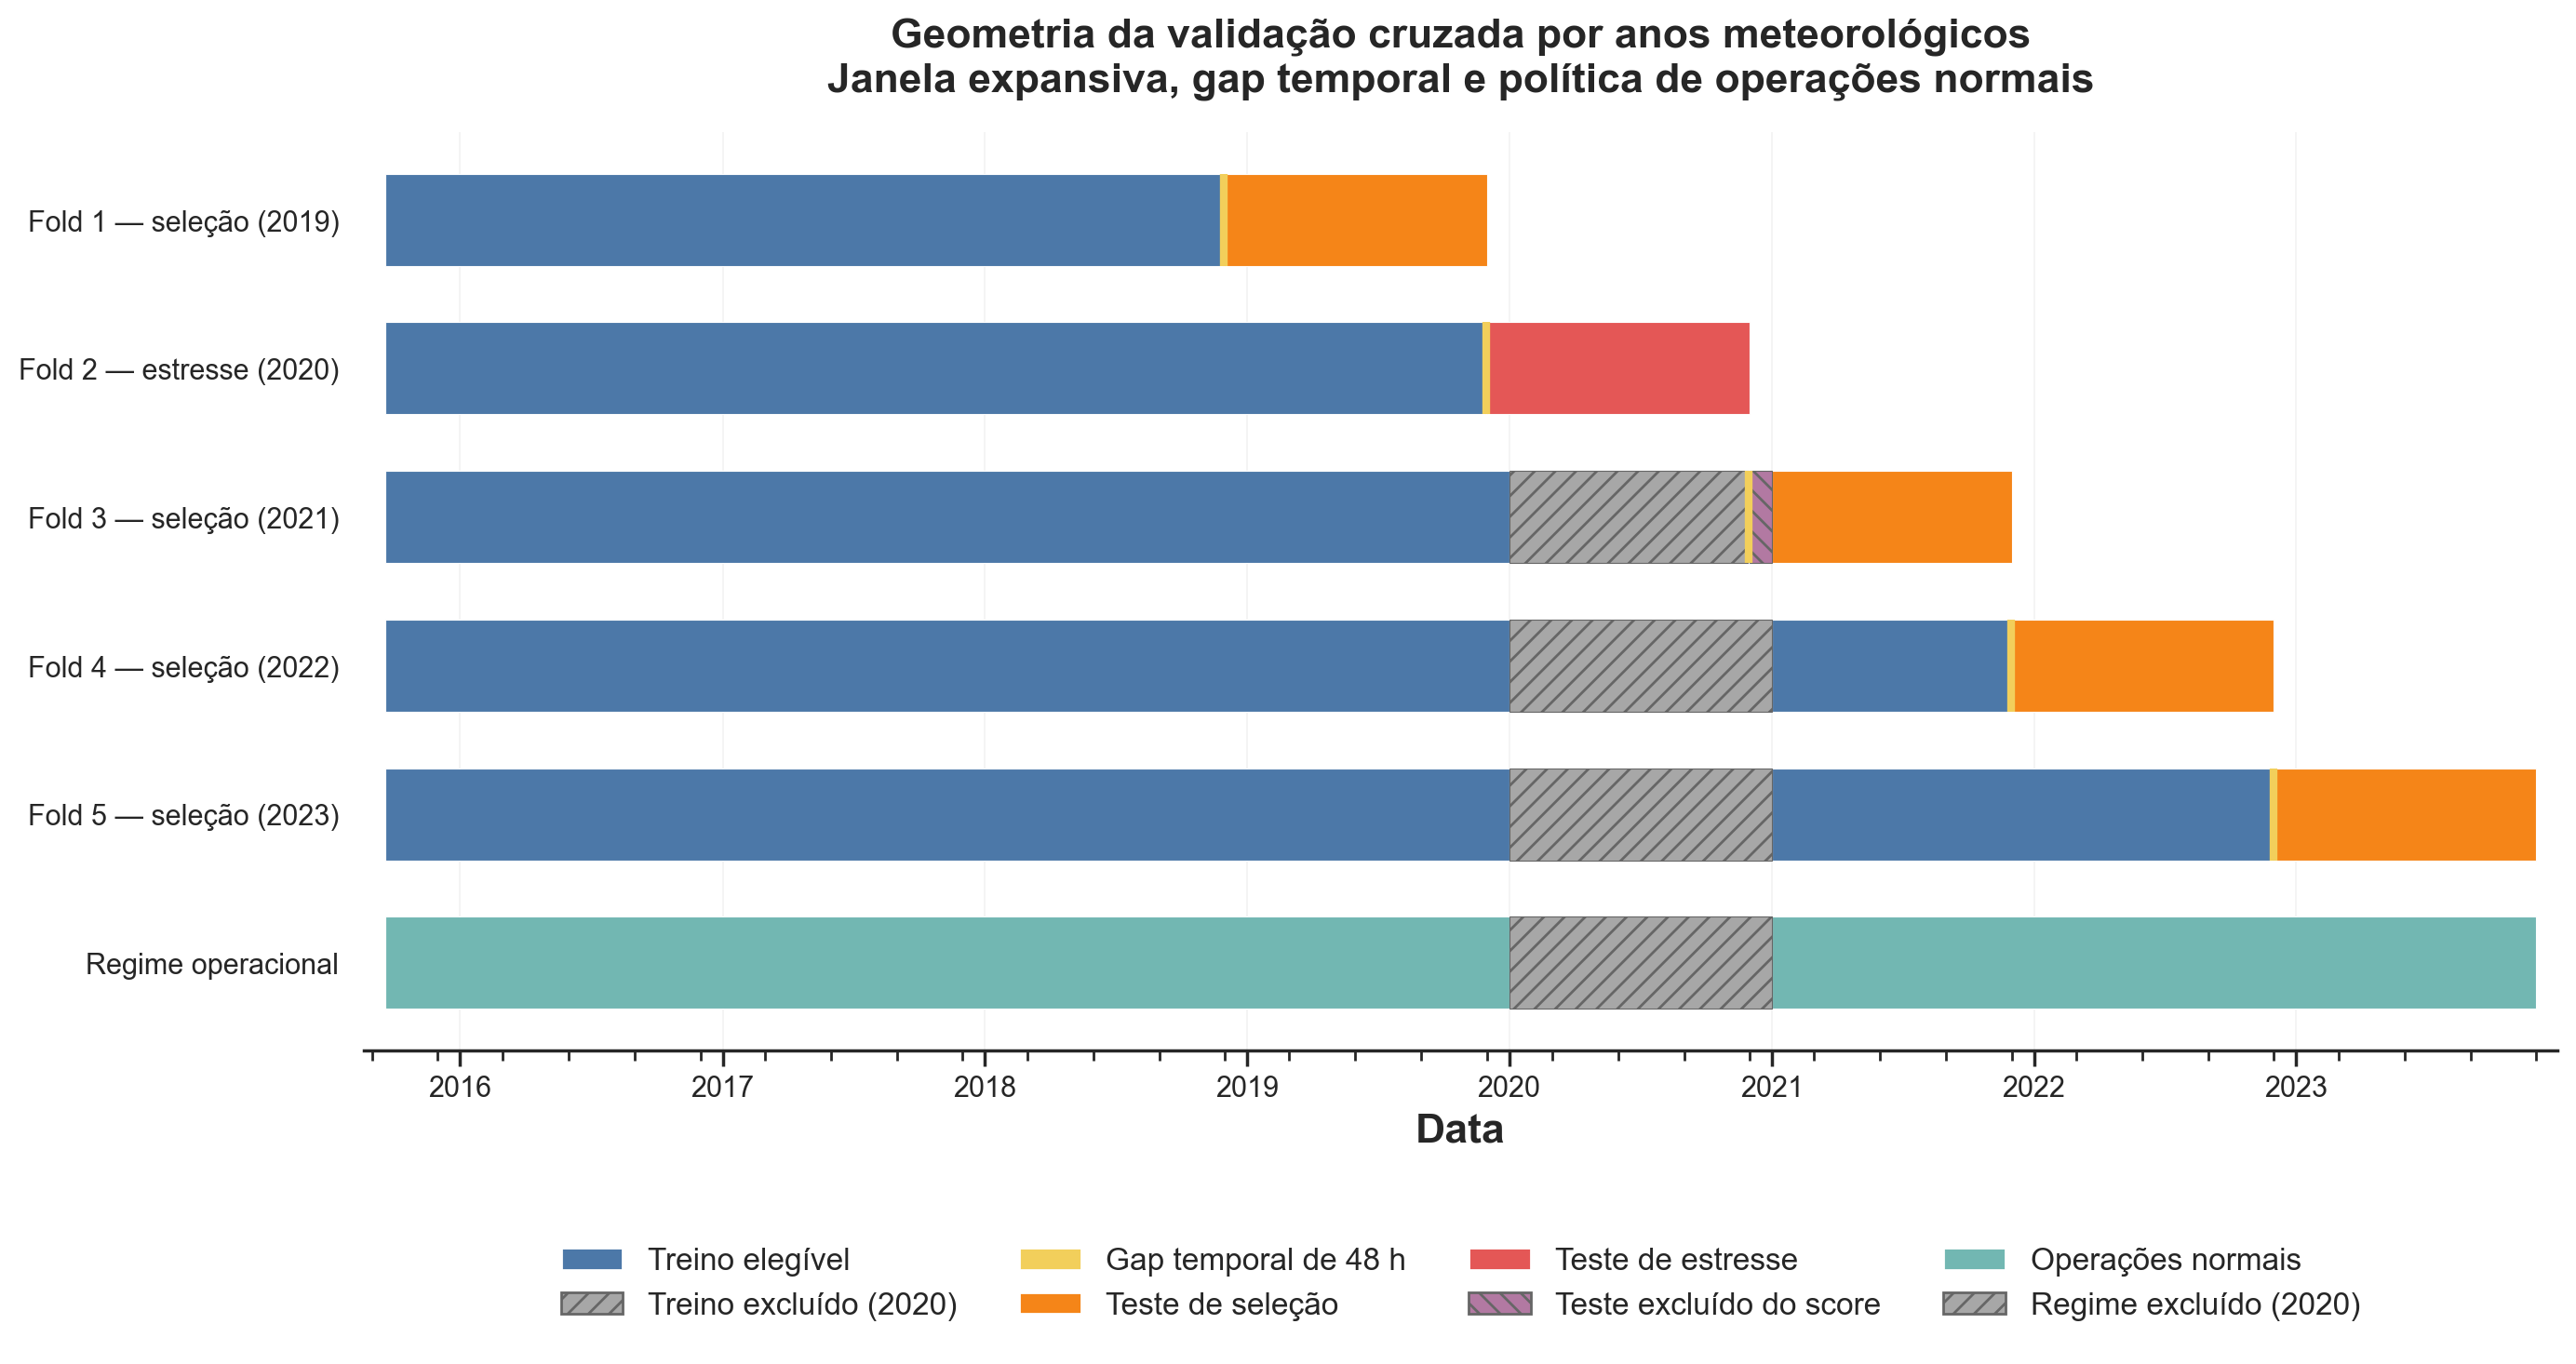

In [5]:
display(reports.fold_audit_report(development, lang=lang))
reports.plot_fold_audit(development, lang=lang)

> ### Insight
>
> A mudança de regime foi tratada como uma redefinição explícita do objetivo, e não como uma limpeza oportunista. O ano civil de 2020 foi preservado na fonte, no fingerprint do dataset e no fold meteorológico de estresse, mas suas linhas foram retiradas do ajuste e da métrica que escolhe o champion.
>
> No fold meteorológico de 2021, dezembro de 2020 também foi excluído da pontuação normal. Dessa forma, nenhuma hora pertencente ao intervalo declarado participa parcialmente do objetivo apenas por atravessar a fronteira entre ano civil e ano meteorológico.
>
> No diagrama, a interrupção cinza nos treinos posteriores a 2020 não representa ausência de dados: ela documenta as observações deliberadamente impedidas de participar do ajuste. O bloco vermelho permanece como teste de estresse, enquanto os blocos laranja são os únicos que contribuem para o critério de seleção.

## 5. Features candidatas e o ramo de cada uma

As variáveis meteorológicas novas, a categoria `Rush_Period` e `Elapsed_Hours`, derivada apenas do timestamp, são mantidas no espaço candidato. `Year` permanece excluído porque poderia representar diretamente a curva acumulada de crescimento. `is_anomalous_2020` também não é oferecida ao modelo, pois foi produzida retrospectivamente a partir da demanda.

As representações contínua e categórica de insolação e cobertura de nuvens coexistem deliberadamente. A redundância é resolvida pelos seletores de features dentro da busca. Os valores ausentes são imputados dentro do ramo correspondente, com estatísticas aprendidas apenas no treino de cada fold.

In [6]:
reports.feature_space_report(config, lang=lang)

,Feature candidata,Ramo de pré-processamento
0,Temperature(C),Numérico
1,Dew point temperature(C),Numérico
2,Ground Temp(C),Numérico
3,Humidity(%),Numérico
4,Solar Radiation (MJ/m2),Numérico
5,Wind speed (m/s),Numérico
6,Visibility (10m),Numérico
7,Sunshine (hr),Numérico
8,Cloud Cover (oktas),Numérico
9,Month,Numérico


## 6. Pré-processamento dinâmico condicionado ao estimator

O pré-processamento não é fixado antecipadamente. Para cada trial, são escolhidos conjuntamente o `modeler_name`, o encoder, a função de perda, os hiperparâmetros, a estratégia de orçamento do boosting e a estratégia do alvo, sempre de acordo com a família do estimator.

No perfil refinado, `NoSelector` é mantido para os boosters a partir da evidência da busca exploratória, enquanto o Ridge continua podendo avaliar seletores compatíveis com seus coeficientes. As decisões substantivas de representação temporal e codificação categórica permanecem dinâmicas.

Na estratégia direta, `log1p` é mantida para os estimators em geral e o alvo bruto é reaberto somente para o CatBoost. Na estratégia `robust_trend_residual`, uma tendência log-linear com sazonalidade mensal é estimada apenas sobre as linhas elegíveis do treino e o pipeline aprende o resíduo logarítmico. A demanda é reconstruída na escala original antes do cálculo das métricas.

In [7]:
reports.search_space_report(config, lang=lang)

,Estimator,Família,Estratégias disponíveis,Espaço de representação (modeler_name),Espaço de encoders,Espaço de seleção de features,Espaço de orçamento do boosting
0,DummyRegressor,baseline,1,linear_modeling,"OrdinalEncoder, MeanEncoder, CountFrequencyEnc...",NoSelector,não aplicável
1,Ridge,linear,8,"linear_modeling, Normalizers, Polynomial, Sin_...","OrdinalEncoder, MeanEncoder, CountFrequencyEnc...","NoSelector, SelectKBest, RFE, SelectFromModel,...",não aplicável
2,HistGradientBoostingRegressor,hist_gradient_boosting,1,Periodic_Spline,"MeanEncoder, CountFrequencyEncoder",NoSelector,não aplicável
3,XGBRegressor,xgboost,1,linear_modeling,"JamesSteinEncoder, CountFrequencyEncoder",NoSelector,"temporal_early_stopping, fixed_iterations"
4,LGBMRegressor,lightgbm,1,linear_modeling,"CountFrequencyEncoder, QuantileEncoder",NoSelector,"temporal_early_stopping, fixed_iterations"
5,RandomForestRegressor,tree_ensemble,2,"linear_modeling, Periodic_Spline","OrdinalEncoder, CountFrequencyEncoder",NoSelector,não aplicável
6,CatBoostRegressor,catboost,1,Periodic_Spline,"OrdinalEncoder, MeanEncoder, CountFrequencyEnc...",NoSelector,"temporal_early_stopping, fixed_iterations"


> ### Insight
>
> A arquitetura autoral foi ampliada sem ser descaracterizada: a política de regime controla quais linhas podem ser vistas pelo ajuste, enquanto as decisões de representação, encoding, seleção, transformação do alvo e orçamento do booster continuam encapsuladas no pipeline dinâmico e são escolhidas conjuntamente pelo Optuna.
>
> A configuração antiga do CatBoost e os melhores arranjos dos demais estimators foram reaproveitados somente como trials iniciais. Assim, foi preservado o conhecimento acumulado sem impedir que cada família seja novamente julgada sob a mesma visão de operações normais.

## 7. Um pipeline dinâmico amostrado

Um pipeline é construído com escolhas fixadas apenas para inspeção da estrutura. A ordem conceitual é preservada: engenharia de atributos sem acesso ao alvo, representação condicionada à família do estimator, codificação categórica, seleção de features, estratégia do alvo e regressor.

Quando a decomposição é escolhida, o metaestimador externo recebe as features originais, estima a tendência exclusivamente nas linhas elegíveis do treino e delega ao mesmo pipeline dinâmico o aprendizado do resíduo. A política de regime não é transformada em feature e não pode ser aprendida pelo estimator.

In [8]:
sample_pipeline, sample_spec = sample_dynamic_pipeline(development, estimator='Ridge')
display(reports.pipeline_spec_report(sample_spec, lang=lang))
reports.dynamic_pipeline_diagram(sample_pipeline)

,Item,Valor
0,Estimator,Ridge
1,Família,linear
2,Representação (modeler_name),Periodic_Spline
3,Encoder categórico,MeanEncoder
4,Scaler numérico,StandardScaler
5,Normalizador,não utilizado
6,Seletor de features,SelectKBest
7,Transformação do alvo,log1p
8,Estratégia do orçamento de boosting,não utilizado
9,Features entregues ao estimator,não utilizado


## 8. Definição de operações normais e diagnóstico de estresse

O intervalo de 1º de janeiro a 31 de dezembro de 2020 foi declarado antes da nova busca como período de ruptura operacional. A regra é inteiramente temporal e não depende de um limiar de demanda, evitando que o alvo seja usado para escolher quais observações serão removidas.

As linhas desse intervalo não são utilizadas no treino de nenhum fold, no refit final nem na métrica primária. O fold meteorológico de 2020 continua sendo previsto integralmente e suas métricas completas são registradas como estresse. Nos folds de seleção, métricas normais e métricas diagnósticas completas são mantidas lado a lado quando os respectivos blocos contêm alguma hora excluída.

Essa separação permite responder a duas perguntas diferentes. O ranking mede a capacidade de prever demanda sob o objetivo operacional declarado, enquanto o diagnóstico de estresse documenta como o mesmo pipeline se comportaria diante da ruptura histórica preservada.

## 9. Execução da busca conjunta

A busca é realizada por uma única chamada de workflow. Estudos novos são identificados pela versão do código, geometria dos folds, pesos, política e fingerprint do regime, perfil de busca, estratégia do alvo, dataset e ambiente numérico; resultados produzidos por protocolos anteriores não podem ser anexados silenciosamente.

Para XGBoost, LightGBM e CatBoost, early stopping temporal e orçamento fixo competem como estratégias explícitas. Quando o early stopping é escolhido, uma cauda interna é retirada somente do treino elegível de cada fold. Quando o orçamento fixo é escolhido, o número de iterações é amostrado e o teste anual continua reservado exclusivamente à pontuação.

No modo `full`, cada estudo é encerrado ao atingir 100 trials ou quatro horas cumulativas. As configurações enfileiradas contam nesse total, e uma retomada utiliza apenas as trials e o tempo ainda disponíveis.

Como a busca definitiva já foi concluída, a execução publicada utiliza por padrão o snapshot leve dos resultados validados. Esse artefato contém somente especificações e diagnósticos agregados de CV; modelos, estudos Optuna, previsões e observações do holdout não são desserializados. Uma nova busca somente é iniciada quando `RETRAIN_MODELS` é alterado explicitamente para `True`.

In [9]:
RETRAIN_MODELS = False

if RETRAIN_MODELS:
    results = run_model_selection(config, development)
else:
    results = load_model_selection_results(config, development)

2026-07-29 14:46:11,341 — src.mlflow_integration — INFO — MLflowTracker inicializado para 'bike_sharing_demand_v4'
2026-07-29 14:46:11,362 — src.tracking — INFO — MLflow tracking: file:PROJECT_ROOT\mlruns  experiment: bike_sharing_demand_v4_model_selection
2026-07-29 14:46:11,420 — src.mlflow_integration — INFO — Experiment 'bike_sharing_demand_v4_model_selection' ready (id=715367045715289141)
[I 2026-07-29 14:46:11,993] A new study created in RDB with name: DummyRegressor__full__ForwardMeteorologicalYearSplit_v3_normal_operations__703702360d84__24f188a95febd94d__temporal_optimizer_v7__broad__direct__8f80d9216d47a792
[I 2026-07-29 14:46:27,449] Trial 0 finished with value: 3733.9975301239633 and parameters: {'modeler_name': 'linear_modeling', 'encoder': 'MeanEncoder', 'standardizer': 'MaxAbsScaler', 'strategy': 'mean', 'selector': 'NoSelector', 'target_transform': 'log1p'}. Best is trial 0 with value: 3733.9975301239633.
[I 2026-07-29 14:46:43,572] Trial 1 finished with value: 3651.590

> ### Insight
>
> A busca `full` foi concluída para os seis estimators candidatos e para o baseline. CatBoost, HistGradientBoosting, Random Forest, LightGBM e XGBoost atingiram as 100 trials planejadas; para o Ridge, 66 trials foram concluídas antes que o limite de quatro horas fosse alcançado. Como o Ridge permaneceu afastado do grupo líder, essa interrupção deve ser interpretada como uma limitação da abrangência de sua busca, e não como evidência capaz de alterar o primeiro grupo do ranking.
>
> A melhora não ficou restrita a uma única família. Sob o protocolo de operações normais, foi formado um grupo competitivo por CatBoost, HistGradientBoosting e Random Forest, com R² ponderado entre 0,839 e 0,857 e MAE médio entre 815 e 848 bicicletas por hora. Em contraste, MAE ponderado de 3.652 e R² ponderado de −0,988 foram obtidos pelo DummyRegressor; assim, foi demonstrado que estrutura temporal e meteorológica generalizável foi aprendida pelos modelos líderes.
>
> Nenhuma truncagem sistemática no teto de boosting foi registrada. No CatBoost vencedor, 497 iterações fixas foram escolhidas pelo Optuna, enquanto 1.102 iterações agregadas por early stopping foram utilizadas pelo LightGBM. Um único fold do LightGBM atingiu o teto, mas esse evento isolado não foi confundido com convergência sistematicamente limitada.

## 10. Comparação por validação cruzada

Os estimators são ordenados pelo MAE normal ponderado por recência. O MAE médio não ponderado, RMSE, WAPE, R² médio, R² mediano, R² ponderado e média do valor absoluto do viés por fold também são exibidos para que a escolha não seja interpretada a partir de um único número.

As métricas agregadas de seleção utilizam somente 2019, 2021, 2022 e 2023. As métricas completas do fold de 2020 permanecem disponíveis no diagnóstico por fold, mas não podem alterar a posição do champion.

,Estimator,Papel,Representação,Encoder,Scaler,Seletor,Alvo,Orçamento do boosting,Features,MAE médio normal (CV),...,WAPE médio normal (CV),Viés médio normal (CV),Média do |viés| por fold,Gap de R² (treino-teste),Trials planejadas,Trials concluídas,Motivo do encerramento,Iterações do refit final,Folds no teto de boosting,Run ID
0,CatBoostRegressor,champion,Periodic_Spline,OrdinalEncoder,passthrough,NoSelector,robust_trend_residual,fixed_iterations,41,820.401191,...,0.235199,-400.501401,518.126115,0.139722,100,100,limite de trials,497.0,0,2106a5bf79e945f7a4a9d161e2ee01d3
1,HistGradientBoostingRegressor,candidato,Periodic_Spline,CountFrequencyEncoder,passthrough,NoSelector,robust_trend_residual,None,41,815.019786,...,0.227961,-359.628940,489.208495,0.135518,100,100,limite de trials,NaN,0,381e7061d8ef440e917c792ab38e59f3
2,RandomForestRegressor,candidato,linear_modeling,CountFrequencyEncoder,passthrough,NoSelector,robust_trend_residual,None,25,847.613928,...,0.235579,-240.020959,425.603402,0.152546,100,100,limite de trials,NaN,0,030ef18ea01d46caacbeb2bc0765da61
3,LGBMRegressor,candidato,linear_modeling,CountFrequencyEncoder,passthrough,NoSelector,robust_trend_residual,temporal_early_stopping,25,936.177127,...,0.250890,-241.507045,574.275904,0.142894,100,100,limite de trials,1102.0,1,7a848d2ed71341fa9a4fd7424488e901
4,XGBRegressor,candidato,linear_modeling,JamesSteinEncoder,passthrough,NoSelector,log1p,fixed_iterations,25,1146.470075,...,0.331883,-939.330722,939.330722,0.273618,100,100,limite de trials,420.0,0,9795292e8c384852ab6b6538ef6a15b5
5,Ridge,candidato,Time_steps_as_categories,JamesSteinEncoder,StandardScaler,SequentialFeatureSelector,robust_trend_residual,None,10,1293.085149,...,0.343111,527.621047,582.029203,0.036616,100,66,timeout do estudo,NaN,0,d4b297ac317d4a6683520bec9b15e6d6
6,DummyRegressor,baseline,linear_modeling,QuantileEncoder,RobustScaler,NoSelector,yeo_johnson,None,25,3237.243006,...,0.884902,-3190.739960,3190.739960,0.806281,3,3,limite de trials,NaN,0,51e98fe59af44b9ebca9ba870e32958c


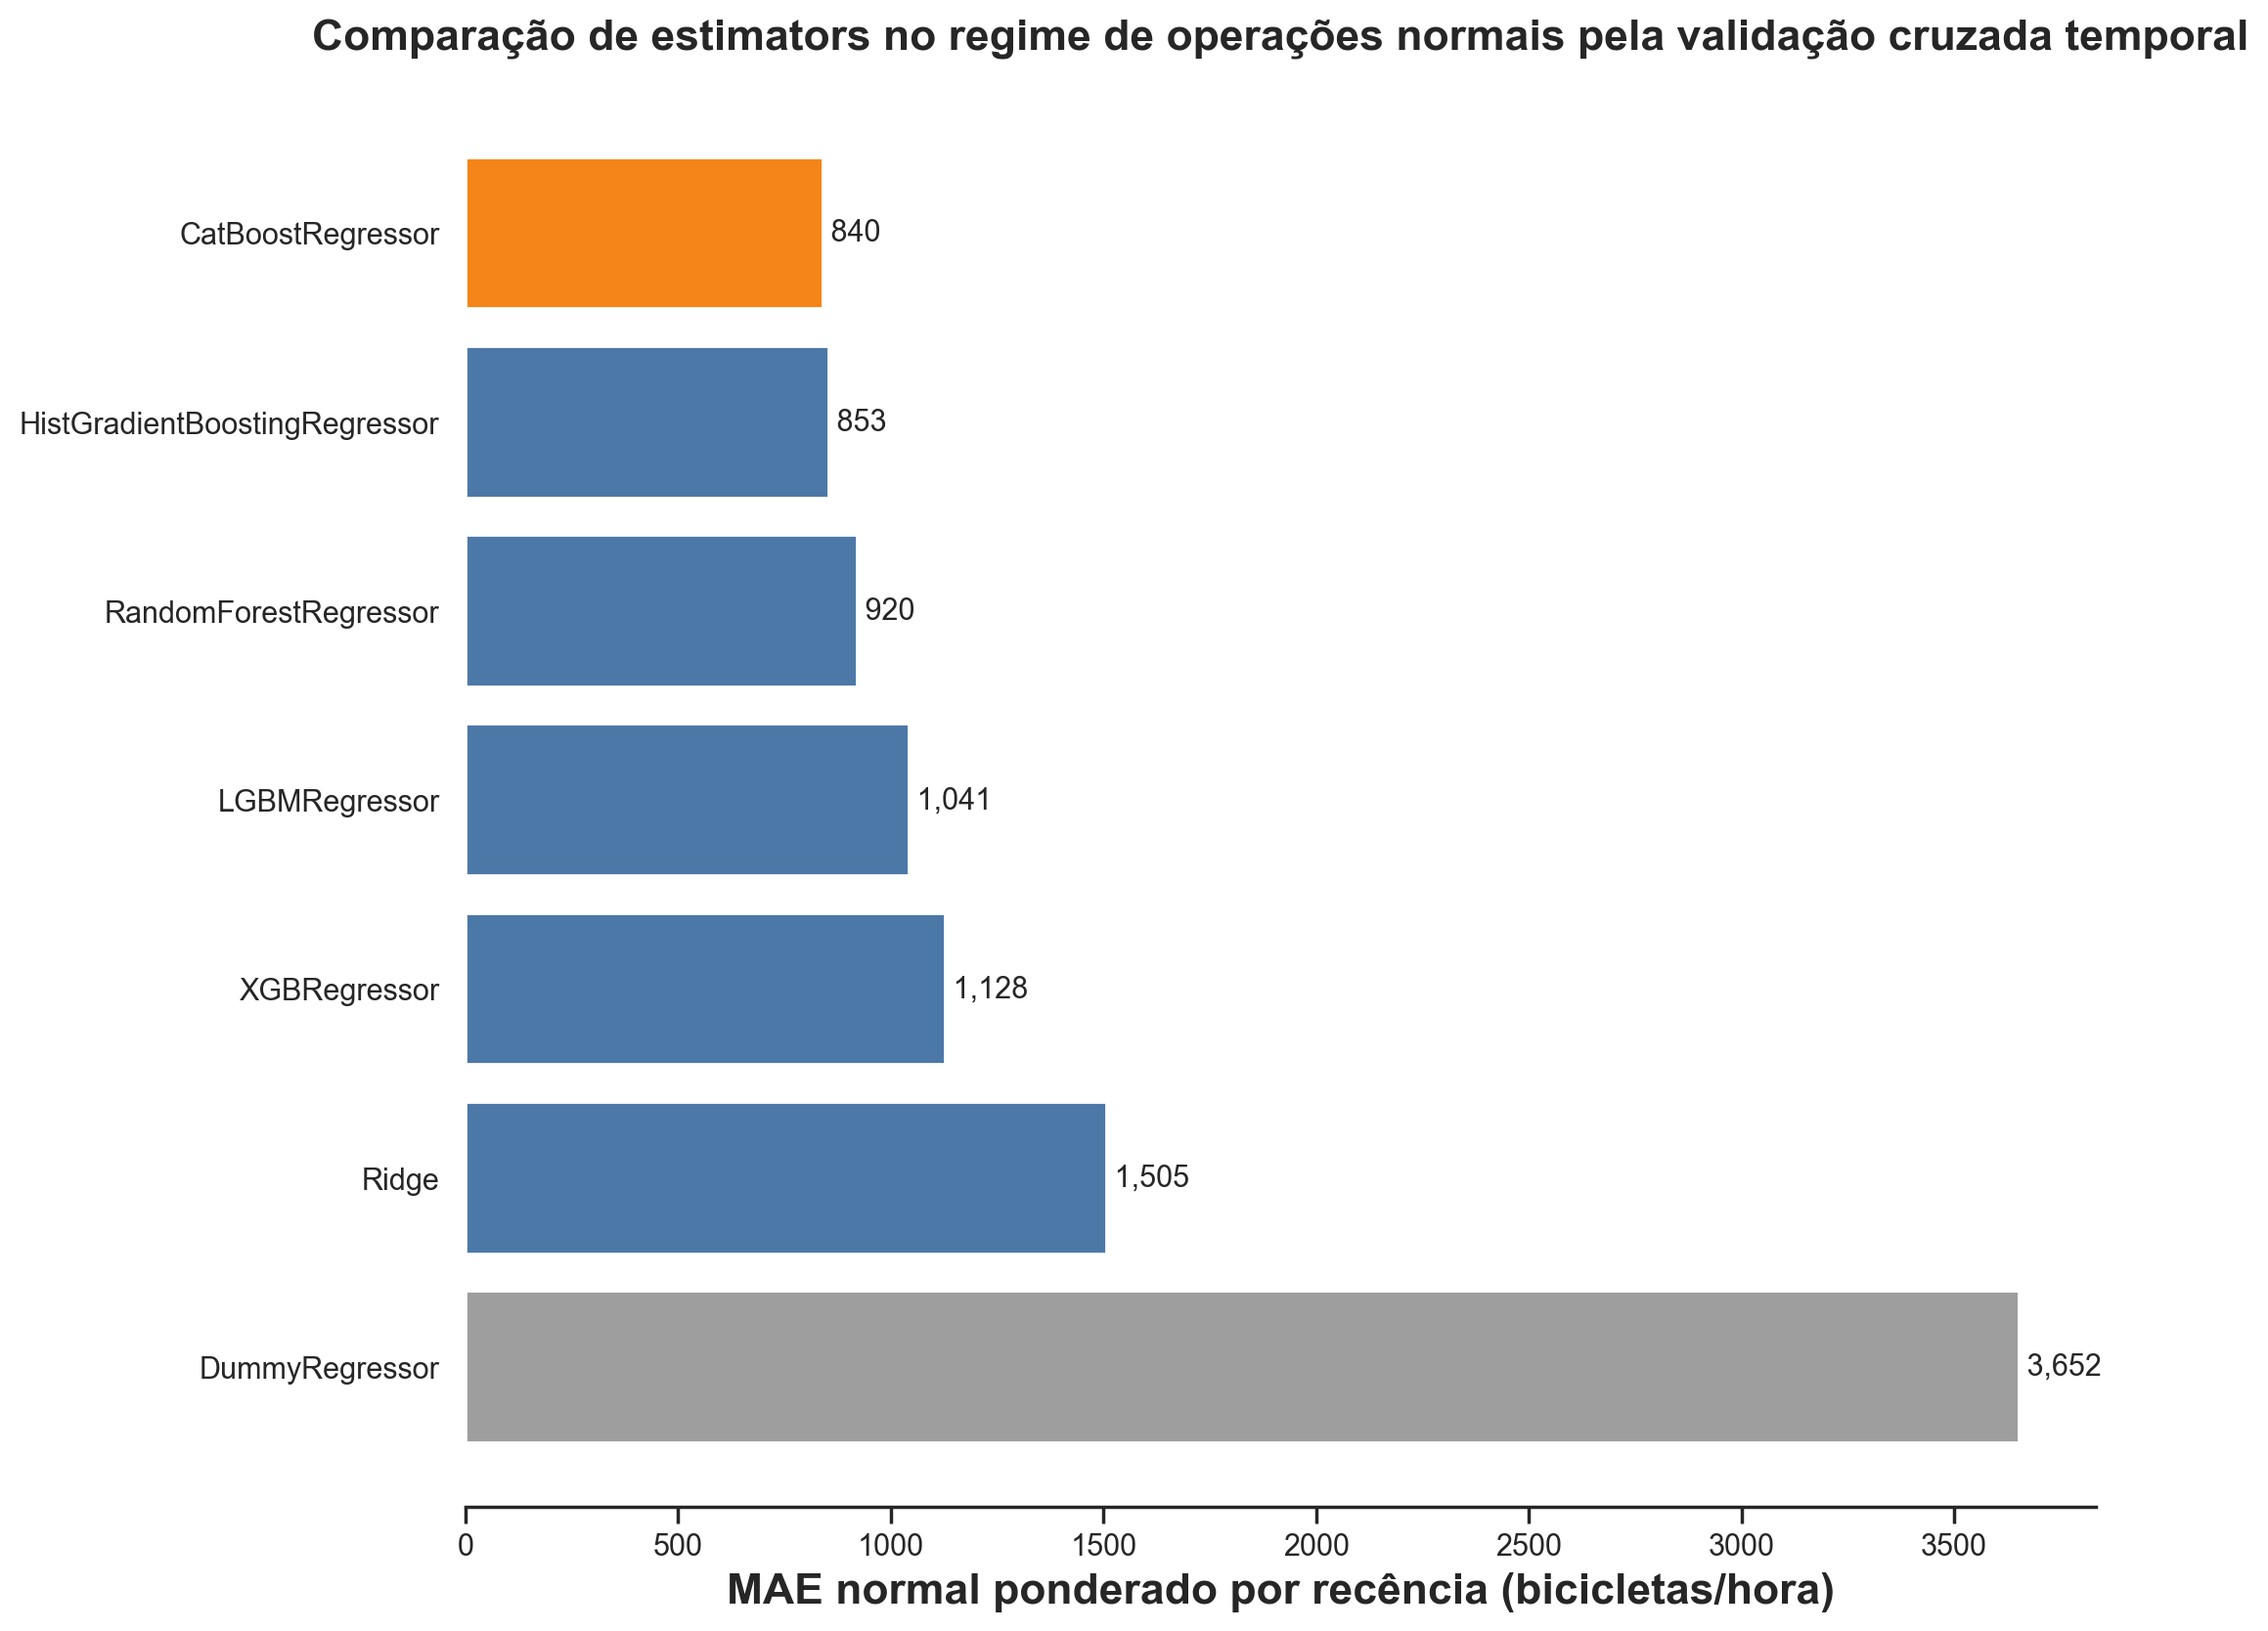

In [10]:
display(reports.comparison_report(results, lang=lang))
reports.plot_comparison(results, lang=lang)

> ### Insight
>
> O CatBoost foi selecionado pelo critério declarado, com MAE normal ponderado de 840,2, R² ponderado de 0,857 e R² médio de 0,839. Uma redução de aproximadamente 77% no MAE ponderado foi obtida em relação ao DummyRegressor. Nos quatro folds normais, valores de R² entre 0,810 e 0,918 foram mantidos, o que sustenta a estabilidade observada e afasta a hipótese de que o resultado agregado tenha sido produzido por um único ano excepcional.
>
> A liderança, contudo, foi estreita e dependente da métrica de seleção. MAE ponderado de 853,0 foi obtido pelo HistGradientBoosting, que apresentou MAE médio ligeiramente menor, de 815,0 contra 820,4, além de WAPE médio menor e R² médio e mediano discretamente maiores. O Random Forest apresentou MAE ponderado de 919,7 e o menor valor médio de |viés| entre os três primeiros. Por isso, CatBoost foi corretamente congelado como champion, mas HistGradientBoosting e Random Forest foram preservados como challengers substantivos, e não apenas formais.

## 11. Diagnóstico por fold, estação e extremos climáticos

O desempenho do candidato selecionado é decomposto por fold. Para os folds de seleção, são mostradas as métricas normais; para todos os folds, inclusive o estresse de 2020, são preservadas as métricas diagnósticas completas. As contagens de treino excluído e de teste efetivamente pontuado tornam o efeito da política verificável.

Os diagnósticos por estação e extremos térmicos são calculados somente sobre as linhas normais dos folds de seleção. Assim, a comparação climática não volta a introduzir silenciosamente o regime retirado do objetivo principal.

In [11]:
display(reports.fold_metrics_report(results, lang=lang))
reports.condition_metrics_report(results, lang=lang)

,Estimator,Fold,Ano meteorológico,Papel,Linhas de treino,Treino excluído,Linhas de teste,Teste usado na seleção,MAE diagnóstico completo,RMSE diagnóstico completo,...,MAE normal,RMSE normal,R² normal,WAPE normal,Viés normal,WAPE diagnóstico completo,Viés diagnóstico completo,Iterações (early stopping),Teto de iterações,Atingiu o teto
0,CatBoostRegressor,1,2019,seleção,27689,0,8715,8715,531.067463,782.778501,...,531.067463,782.778501,0.815006,0.261463,-459.828516,0.261463,-459.828516,None,None,False
1,CatBoostRegressor,2,2020,estresse,36404,0,8759,0,1478.114135,2176.171092,...,NaN,NaN,NaN,NaN,NaN,1.418034,1438.243498,None,None,False
2,CatBoostRegressor,3,2021,seleção,37196,7967,8760,8016,900.347549,1232.299148,...,907.303424,1252.009734,0.812032,0.282839,-481.345596,0.304339,-370.466294,None,None,False
3,CatBoostRegressor,4,2022,seleção,45164,8759,8759,8759,1086.914530,1724.726290,...,1086.914530,1724.726290,0.810150,0.245017,-896.080920,0.245017,-896.080920,None,None,False
4,CatBoostRegressor,5,2023,seleção,53923,8759,8760,8760,756.319349,1211.868065,...,756.319349,1211.868065,0.917577,0.151479,235.249426,0.151479,235.249426,None,None,False


,Estimator,Recorte,Condição,Observações,MAE,RMSE,R²
0,CatBoostRegressor,estação,Outono,8691,1169.254655,1589.391461,0.752003
1,CatBoostRegressor,estação,Primavera,8832,741.801805,1106.493487,0.864830
2,CatBoostRegressor,estação,Verão,8831,998.015360,1333.517171,0.823180
3,CatBoostRegressor,estação,Inverno,7896,333.751742,494.850768,0.808177
4,CatBoostRegressor,faixa de temperatura,extremo frio (5% mais frio),1739,248.852188,375.075004,NaN
5,CatBoostRegressor,faixa de temperatura,extremo quente (5% mais quente),1757,1207.082927,1518.860336,NaN


> ### Insight
>
> Para o CatBoost, R² de 0,815, 0,812, 0,810 e 0,918 foi obtido nos folds normais de 2019, 2021, 2022 e 2023, respectivamente. Embora o MAE tenha variado entre 531 e 1.087 bicicletas por hora, a proporção de variância explicada permaneceu acima de 0,81 em todos os anos admitidos. Em 2023, simultaneamente, o menor WAPE, de 0,151, e o maior R², de 0,918, foram observados, favorecendo o CatBoost quando os folds recentes receberam maior peso.
>
> No fold de estresse de 2020, MAE de 1.478, WAPE de 1,418, R² de −2,355 e viés positivo de 1.438 bicicletas por hora foram registrados. Esse colapso fora do regime normal não deve ser usado para reordenar os candidatos, mas confirma que o modelo não pode ser apresentado como válido para uma ruptura operacional semelhante. A exclusão da pandemia tornou o objetivo normal mais coerente; ela não transformou o evento excluído em um cenário resolvido.
>
> A dificuldade também não foi uniforme entre condições operacionais normais. O outono apresentou MAE de 1.169 e R² de 0,752, enquanto MAE de 334 foi obtido no inverno. Entre os extremos térmicos, o erro no calor extremo, de 1.207, foi quase cinco vezes o observado no frio extremo, de 249. Esses recortes deverão orientar a validação de erros e a interpretação SHAP no notebook 05, principalmente para verificar se a subestimação da alta demanda se concentra em períodos quentes e no outono.

## 12. Champion e challengers

O champion e dois challengers foram identificados entre runs compatíveis do MLflow e ordenados pelo MAE normal ponderado. Foram exigidas correspondências exatas de dataset, estratégia de CV, versão do código, ambiente, estado do Git, política e fingerprint do regime.

Nenhuma métrica do holdout foi consultada. O CatBoost foi promovido pelo MAE ponderado de 840,2, seguido pelo HistGradientBoosting, com 853,0, e pelo Random Forest, com 919,7. A proximidade entre os dois primeiros e as vantagens secundárias observadas para os challengers justificam que os três sejam encaminhados à validação final, sem que o ranking da validação cruzada seja tratado como uma conclusão antecipada sobre o holdout.

In [12]:
reports.selection_report(results, lang=lang)

,Papel,Estimator,MAE médio normal (CV),Representação,Encoder,Scaler,Seletor,Alvo,Orçamento do boosting,Iterações do refit final,Folds no teto de boosting,Trials concluídas,Motivo do encerramento,Modo,Run ID
0,champion,CatBoostRegressor,820.401191,Periodic_Spline,OrdinalEncoder,passthrough,NoSelector,robust_trend_residual,fixed_iterations,497,0,100,limite de trials,full,2106a5bf79e945f7a4a9d161e2ee01d3
1,challenger,HistGradientBoostingRegressor,815.019786,Periodic_Spline,CountFrequencyEncoder,passthrough,NoSelector,robust_trend_residual,None,None,0,100,limite de trials,full,381e7061d8ef440e917c792ab38e59f3
2,challenger,RandomForestRegressor,847.613928,linear_modeling,CountFrequencyEncoder,passthrough,NoSelector,robust_trend_residual,None,None,0,100,limite de trials,full,030ef18ea01d46caacbeb2bc0765da61


## 13. Artefatos e hand-off para o notebook 05

Os candidatos selecionados são persistidos em `dataset/normal_operations`, acompanhados de um manifesto que registra a run, o estimator, o modo de execução, as versões do código e da validação, os fingerprints do dataset, do ambiente e do regime, os hiperparâmetros, a combinação completa do pipeline, o orçamento final de iterações, o motivo de encerramento, o URI do modelo e as métricas de validação.

A correspondência entre run e pipeline é verificada no próprio objeto entregue por meio de um carimbo de proveniência. O modelo é registrado com dependências fixadas e com o código-fonte necessário à desserialização. Em modo `full`, a run é recusada quando o artefato não pode ser relido de forma autocontida.

O congelamento definitivo também é recusado quando um booster com early stopping apresenta truncagem sistemática no teto. Essa verificação não é aplicada a uma trial que escolheu deliberadamente um orçamento fixo, pois nesse caso o número de árvores é um hiperparâmetro avaliado e não um limite acidental.

In [13]:
reports.handoff_report(results, lang=lang)

,Item,Valor
0,Modo de execução,full
1,Artefatos provisórios,False
2,Manifesto gravado em,PROJECT_ROOT/...
3,Experimento MLflow,bike_sharing_demand_v4_model_selection
4,Run ID do champion,2106a5bf79e945f7a4a9d161e2ee01d3
5,URI do modelo do champion,runs:/2106a5bf79e945f7a4a9d161e2ee01d3/model
6,Fingerprint do dataset,24f188a95febd94d
7,Política de regime,normal_operations
8,Fingerprint do regime,1043b392ad5e2806
9,Ambiente de execução,Bike-Sharing (8f80d9216d47a792)


> ### Insight
>
> O manifesto definitivo foi gravado em `dataset/normal_operations/candidates_v4`, e os artefatos autocontidos do CatBoost, do HistGradientBoosting e do Random Forest foram conferidos após o registro. O champion ficou associado à run `2106a5bf79e945f7a4a9d161e2ee01d3`, sob o ambiente `Bike-Sharing` e o fingerprint de regime `1043b392ad5e2806`.
>
> A política de operações normais foi transportada no manifesto e nas tags do MLflow. Com isso, um modelo selecionado sobre todos os anos não poderá ser confundido com um candidato produzido pelo novo objetivo, ainda que o estimator e o dataset de origem sejam os mesmos. O notebook 05 poderá consumir os três artefatos sem reabrir a busca e continuará sendo o único ponto autorizado a materializar e avaliar o holdout.

## 14. Arquitetura preservada e desvios em relação à v3

A arquitetura de pré-processamento dinâmico condicionado ao estimator foi preservada. A política de regime foi adicionada como uma restrição de elegibilidade das linhas, e a correção de tendência continua encapsulada como estratégia de alvo do pipeline.

O espaço refinado foi ampliado onde a evidência exigia uma nova comparação. XGBoost, LightGBM e CatBoost podem escolher entre early stopping temporal e iterações fixas; todos os estimators recebem novamente a oportunidade de competir sob o objetivo normal; e configurações previamente competitivas são avaliadas antes da amostragem livre.

O modo categórico nativo do CatBoost ainda não é ativado. A comparação permanece baseada nos encoders compartilhados pela arquitetura dinâmica, garantindo que a mudança desta rodada seja atribuível ao regime e ao orçamento do boosting, e não à introdução simultânea de uma interface categórica exclusiva.

## 15. Síntese

O objetivo desta seleção foi redefinido como previsão de demanda em condições operacionais normais. O ano civil de 2020 foi preservado como evidência histórica e diagnóstico de estresse, mas foi excluído do ajuste, do refit final e da métrica primária por uma regra temporal declarada que não consulta o alvo.

Quatro folds meteorológicos foram utilizados na seleção, com pesos crescentes para 2022 e 2023. O fold de 2020 foi previsto e reportado separadamente. A distinção entre métricas normais e diagnósticas impediu que a ruptura voltasse a dominar o ranking e, ao mesmo tempo, evitou que seu efeito fosse ocultado.

Todos os estimators foram novamente avaliados. CatBoost, HistGradientBoosting e Random Forest formaram o grupo líder, com R² ponderado entre 0,839 e 0,857. A estratégia `robust_trend_residual` foi selecionada para os três, embora representações e encoders distintos tenham sido escolhidos pelo pipeline dinâmico. O XGBoost preferiu a estratégia direta com `log1p`, mas permaneceu abaixo do grupo líder, demonstrando que a resposta à nova definição de regime dependeu da combinação entre estimator e pré-processamento.

O CatBoost foi congelado como champion pelo MAE normal ponderado de 840,2, mas a diferença de apenas 12,8 bicicletas por hora para o HistGradientBoosting foi pequena. O HistGradientBoosting apresentou melhores MAE médio, WAPE médio e R² mediano, enquanto o Random Forest apresentou menor |viés| médio entre os três primeiros. Assim, a escolha do champion foi respeitada sem que evidências favoráveis aos challengers fossem apagadas.

A estabilidade da proposta foi sustentada por R² superior a 0,81 nos quatro folds normais do champion e pela ampla distância em relação ao baseline. A validade permaneceu restrita, entretanto, às condições operacionais normais: R² de −2,355 foi obtido no fold de estresse de 2020, e os maiores erros normais foram concentrados no outono e no calor extremo. No notebook 05, o holdout ainda intocado deverá ser utilizado uma única vez para validação comparativa, análise de resíduos e interpretação SHAP dos três candidatos congelados.